In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    precision_recall_fscore_support,
    f1_score
)
import time
import os
import joblib

In [2]:
print("\n📂 Loading data...")

X_train = pd.read_csv('data_ml/X_train.csv')
X_test = pd.read_csv('data_ml/X_test.csv')
y_train = pd.read_csv('data_ml/y_train.csv').squeeze()
y_test = pd.read_csv('data_ml/y_test.csv').squeeze()

print(f"   Train: {X_train.shape}")
print(f"   Test:  {X_test.shape}")
print(f"   Features: {X_train.shape[1]}")



📂 Loading data...
   Train: (3333, 11)
   Test:  (834, 11)
   Features: 11


In [3]:
print("\n🔬 Defining 6 experiments...")

experiments = [
    {
        'name': 'Exp 1: Baseline',
        'description': 'Small shallow forest - baseline',
        'params': {
            'n_estimators': 50,
            'max_depth': 10,
            'min_samples_split': 50,
            'min_samples_leaf': 20,
            'max_features': 'sqrt',
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
    },
    {
        'name': 'Exp 2: Medium',
        'description': 'Balanced configuration',
        'params': {
            'n_estimators': 100,
            'max_depth': 15,
            'min_samples_split': 20,
            'min_samples_leaf': 10,
            'max_features': 'sqrt',
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
    },
    {
        'name': 'Exp 3: Large',
        'description': 'Many trees for stability',
        'params': {
            'n_estimators': 200,
            'max_depth': 15,
            'min_samples_split': 20,
            'min_samples_leaf': 10,
            'max_features': 'sqrt',
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
    },
    {
        'name': 'Exp 4: Deep',
        'description': 'Deeper trees test',
        'params': {
            'n_estimators': 100,
            'max_depth': 25,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'max_features': 'sqrt',
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
    },
    {
        'name': 'Exp 5: Less features',
        'description': 'log2 features per split',
        'params': {
            'n_estimators': 100,
            'max_depth': 15,
            'min_samples_split': 20,
            'min_samples_leaf': 10,
            'max_features': 'log2',
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
    },
    {
        'name': 'Exp 6: Optimized',
        'description': 'Best parameters combined',
        'params': {
            'n_estimators': 200,
            'max_depth': 20,
            'min_samples_split': 15,
            'min_samples_leaf': 8,
            'max_features': 'sqrt',
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
    }
]


🔬 Defining 6 experiments...


In [4]:
print("\n" + "="*80)
print("RUNNING EXPERIMENTS WITH 5-FOLD CROSS-VALIDATION")
print("="*80)

results = []

for i, exp in enumerate(experiments, 1):
    print(f"\n{exp['name']}")
    print("-"*80)
    print(f"Description: {exp['description']}")
    
    # Create model
    rf = RandomForestClassifier(**exp['params'])
    
    # Cross-validation on training set (5-fold)
    print(f"\n⏱️  Running 5-fold cross-validation...")
    cv_start = time.time()
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_time = time.time() - cv_start
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    print(f"   CV Accuracy: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"   CV Time: {cv_time:.1f}s")
    
    # Train on full training set
    print(f"\n⏱️  Training on full training set...")
    train_start = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - train_start
    
    # Predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    f1_macro = f1_score(y_test, y_test_pred, average='macro')
    f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    
    # Per-class metrics
    _, _, f1, _ = precision_recall_fscore_support(
        y_test, y_test_pred, labels=[0,1,2,3]
    )
    
    # Store results
    result = {
        'name': exp['name'],
        'description': exp['description'],
        'n_est': exp['params']['n_estimators'],
        'depth': exp['params']['max_depth'],
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'overfit': train_acc - test_acc,
        'cv_time': cv_time,
        'train_time': train_time,
        'f1_0': f1[0],
        'f1_1': f1[1],
        'f1_2': f1[2],
        'f1_3': f1[3],
        'model': rf
    }
    results.append(result)
    
    # Print summary
    print(f"\n📊 Results:")
    print(f"   CV Accuracy:    {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"   Train Accuracy: {train_acc:.4f}")
    print(f"   Test Accuracy:  {test_acc:.4f}")
    print(f"   F1-Macro:       {f1_macro:.4f}")
    print(f"   Overfitting:    {result['overfit']:.4f}")
    print(f"   Train Time:     {train_time:.1f}s")
    
    # Evaluation
    if result['overfit'] > 0.1:
        print(f"   ⚠️  HIGH overfitting!")
    elif result['overfit'] > 0.05:
        print(f"   ⚠️  Moderate overfitting")
    else:
        print(f"   ✅ Good generalization")
    
    # CV vs Test comparison
    cv_test_diff = abs(cv_mean - test_acc)
    if cv_test_diff < 0.02:
        print(f"   ✅ CV predicts test well (diff: {cv_test_diff:.4f})")
    else:
        print(f"   ⚠️  CV-Test mismatch (diff: {cv_test_diff:.4f})")


RUNNING EXPERIMENTS WITH 5-FOLD CROSS-VALIDATION

Exp 1: Baseline
--------------------------------------------------------------------------------
Description: Small shallow forest - baseline

⏱️  Running 5-fold cross-validation...
   CV Accuracy: 0.7483 (+/- 0.0109)
   CV Time: 7.4s

⏱️  Training on full training set...

📊 Results:
   CV Accuracy:    0.7483 (+/- 0.0109)
   Train Accuracy: 0.7939
   Test Accuracy:  0.7242
   F1-Macro:       0.7527
   Overfitting:    0.0697
   Train Time:     0.3s
   ⚠️  Moderate overfitting
   ⚠️  CV-Test mismatch (diff: 0.0241)

Exp 2: Medium
--------------------------------------------------------------------------------
Description: Balanced configuration

⏱️  Running 5-fold cross-validation...
   CV Accuracy: 0.7594 (+/- 0.0157)
   CV Time: 6.2s

⏱️  Training on full training set...

📊 Results:
   CV Accuracy:    0.7594 (+/- 0.0157)
   Train Accuracy: 0.8506
   Test Accuracy:  0.7470
   F1-Macro:       0.7754
   Overfitting:    0.1036
   Train Tim

In [5]:
print("\n" + "="*80)
print("RESULTS SUMMARY - ALL EXPERIMENTS")
print("="*80 + "\n")

# Create comparison table
df_results = pd.DataFrame([
    {
        'Experiment': r['name'],
        'Trees': r['n_est'],
        'Depth': r['depth'],
        'CV Acc': f"{r['cv_mean']:.4f}",
        'Test Acc': f"{r['test_acc']:.4f}",
        'F1': f"{r['f1_macro']:.4f}",
        'Overfit': f"{r['overfit']:.4f}",
        'Time': f"{r['train_time']:.1f}s"
    }
    for r in results
])

print(df_results.to_string(index=False))

# Find best model based on CV score
best_cv_idx = np.argmax([r['cv_mean'] for r in results])
best_cv = results[best_cv_idx]

# Find best model based on test score
best_test_idx = np.argmax([r['test_acc'] for r in results])
best_test = results[best_test_idx]

print(f"\n🏆 BEST MODEL (by CV):   {best_cv['name']}")
print(f"   CV Accuracy:  {best_cv['cv_mean']:.4f} (+/- {best_cv['cv_std']:.4f})")
print(f"   Test Accuracy: {best_cv['test_acc']:.4f}")

print(f"\n🏆 BEST MODEL (by Test): {best_test['name']}")
print(f"   CV Accuracy:  {best_test['cv_mean']:.4f} (+/- {best_test['cv_std']:.4f})")
print(f"   Test Accuracy: {best_test['test_acc']:.4f}")

# Use CV best as final model
best = best_cv
print(f"\n✅ SELECTED: {best['name']} (based on cross-validation)")


RESULTS SUMMARY - ALL EXPERIMENTS

          Experiment  Trees  Depth CV Acc Test Acc     F1 Overfit Time
     Exp 1: Baseline     50     10 0.7483   0.7242 0.7527  0.0697 0.3s
       Exp 2: Medium    100     15 0.7594   0.7470 0.7754  0.1036 0.4s
        Exp 3: Large    200     15 0.7606   0.7506 0.7784  0.1033 0.8s
         Exp 4: Deep    100     25 0.7759   0.7662 0.7913  0.1339 0.4s
Exp 5: Less features    100     15 0.7594   0.7470 0.7754  0.1036 0.4s
    Exp 6: Optimized    200     20 0.7645   0.7602 0.7861  0.1081 0.8s

🏆 BEST MODEL (by CV):   Exp 4: Deep
   CV Accuracy:  0.7759 (+/- 0.0118)
   Test Accuracy: 0.7662

🏆 BEST MODEL (by Test): Exp 4: Deep
   CV Accuracy:  0.7759 (+/- 0.0118)
   Test Accuracy: 0.7662

✅ SELECTED: Exp 4: Deep (based on cross-validation)


In [6]:
print("\n💾 Saving results...")
os.makedirs('output_ml', exist_ok=True)

# Detailed results CSV
detailed_results = pd.DataFrame([
    {
        'Experiment': r['name'],
        'Description': r['description'],
        'n_estimators': r['n_est'],
        'max_depth': r['depth'],
        'CV_Mean': f"{r['cv_mean']:.4f}",
        'CV_Std': f"{r['cv_std']:.4f}",
        'Train_Acc': f"{r['train_acc']:.4f}",
        'Test_Acc': f"{r['test_acc']:.4f}",
        'F1_Macro': f"{r['f1_macro']:.4f}",
        'F1_Weighted': f"{r['f1_weighted']:.4f}",
        'Overfitting': f"{r['overfit']:.4f}",
        'CV_Time': f"{r['cv_time']:.1f}",
        'Train_Time': f"{r['train_time']:.1f}",
        'F1_Class_0': f"{r['f1_0']:.4f}",
        'F1_Class_1': f"{r['f1_1']:.4f}",
        'F1_Class_2': f"{r['f1_2']:.4f}",
        'F1_Class_3': f"{r['f1_3']:.4f}",
    }
    for r in results
])

detailed_results.to_csv('output_ml/rf_results.csv', index=False)
print("   ✅ output_ml/rf_results.csv")

# Save best model
joblib.dump(best['model'], 'output_ml/rf_best_model.pkl')
print("   ✅ output_ml/rf_best_model.pkl")


💾 Saving results...
   ✅ output_ml/rf_results.csv
   ✅ output_ml/rf_best_model.pkl


In [7]:
print("\n" + "="*80)
print("BEST MODEL DETAILED ANALYSIS")
print("="*80)

best_model = best['model']
y_test_pred_best = best_model.predict(X_test)

# Classification Report
print(f"\n📋 Classification Report ({best['name']}):\n")
print(classification_report(
    y_test, 
    y_test_pred_best,
    target_names=['Low (<0%)', 'Medium (0-10%)', 'Good (10-20%)', 'High (>20%)']
))

# Confusion Matrix
print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred_best)
print(cm)

# Feature Importance
print("\n🔍 Top 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))


BEST MODEL DETAILED ANALYSIS

📋 Classification Report (Exp 4: Deep):

                precision    recall  f1-score   support

     Low (<0%)       1.00      0.98      0.99       118
Medium (0-10%)       0.80      0.77      0.78       282
 Good (10-20%)       0.63      0.59      0.61       227
   High (>20%)       0.74      0.83      0.78       207

      accuracy                           0.77       834
     macro avg       0.79      0.79      0.79       834
  weighted avg       0.77      0.77      0.76       834


📊 Confusion Matrix:
[[116   2   0   0]
 [  0 218  46  18]
 [  0  50 134  43]
 [  0   4  32 171]]

🔍 Top 10 Most Important Features:
                   feature  importance
    positive_opm_last_year    0.280418
            asset_turnover    0.147842
Profit after tax last year    0.138928
        depreciation_ratio    0.075471
       material_cost_ratio    0.066707
           Sales last year    0.052538
                 log_sales    0.051885
          total_cost_ratio    0.0


📈 Creating visualizations...
   ✅ output_ml/rf_analysis.png


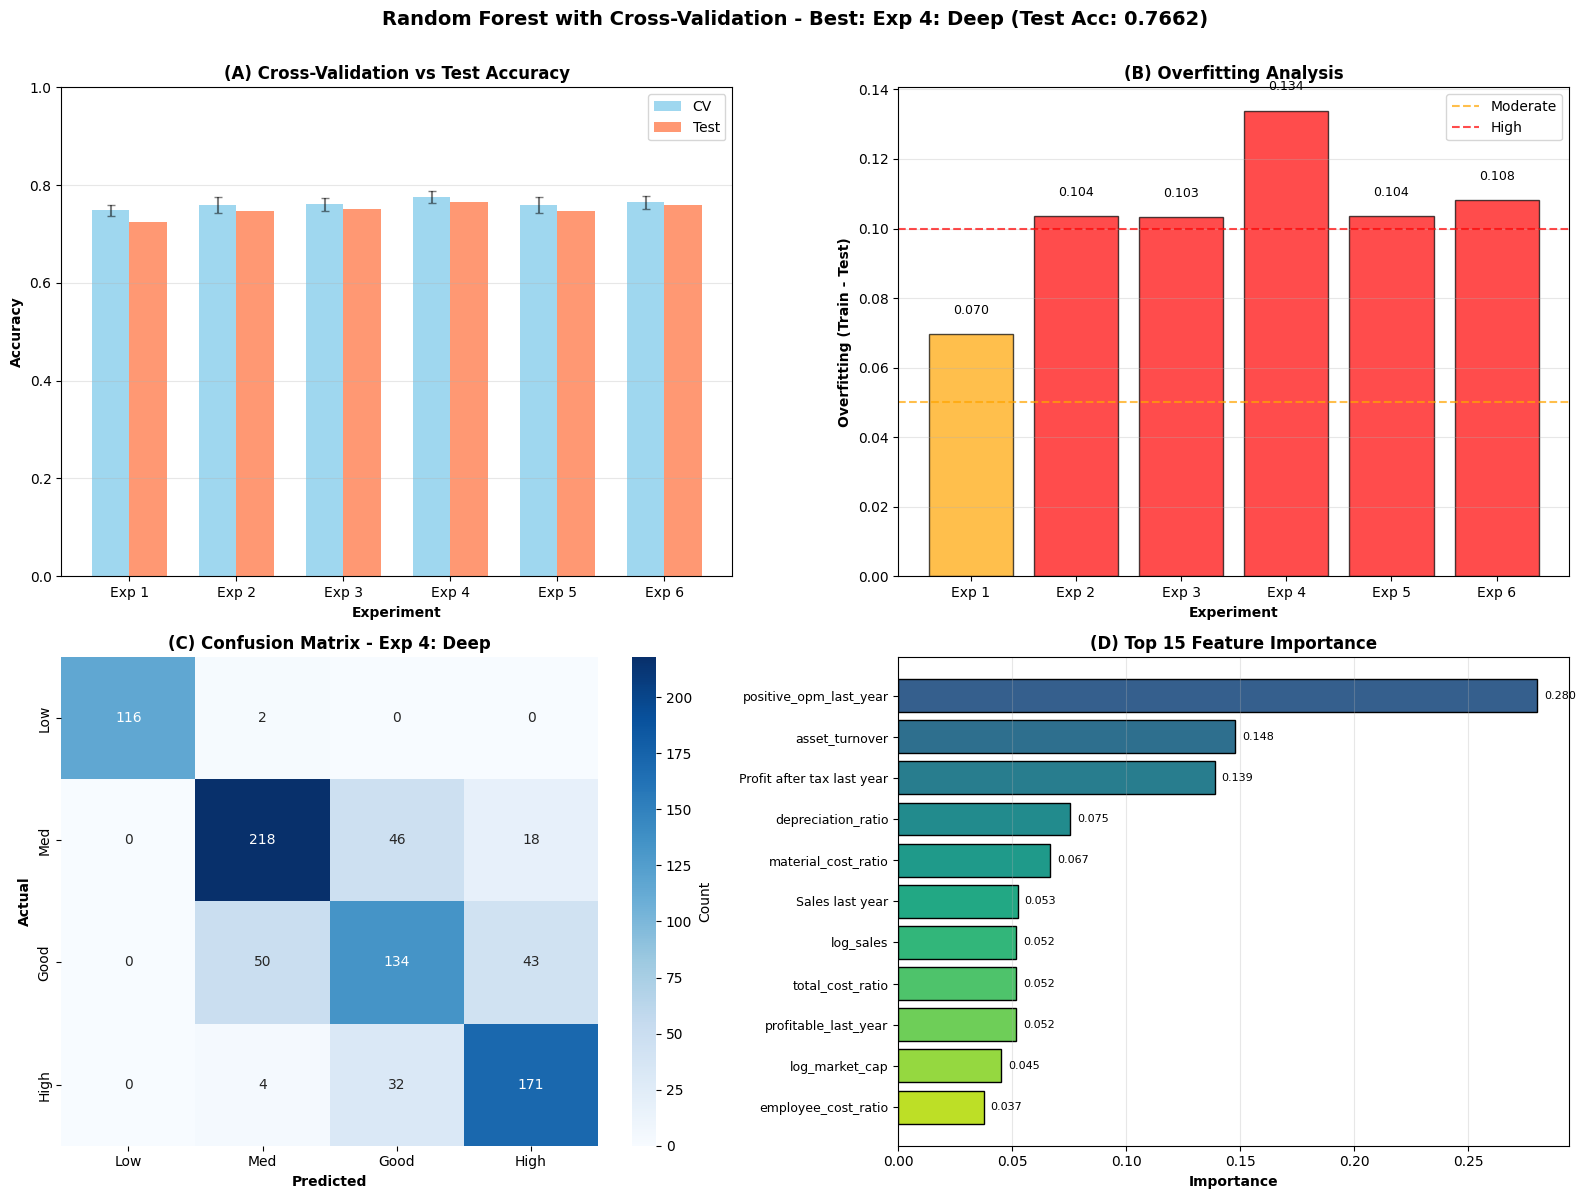

In [8]:
print("\n📈 Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel A: CV vs Test Accuracy
ax1 = axes[0, 0]
x_pos = np.arange(len(results))
cv_accs = [r['cv_mean'] for r in results]
test_accs = [r['test_acc'] for r in results]

width = 0.35
ax1.bar(x_pos - width/2, cv_accs, width, label='CV', alpha=0.8, color='skyblue')
ax1.bar(x_pos + width/2, test_accs, width, label='Test', alpha=0.8, color='coral')

ax1.set_xlabel('Experiment', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('(A) Cross-Validation vs Test Accuracy', fontweight='bold', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"Exp {i+1}" for i in range(len(results))], rotation=0)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# Add error bars for CV
cv_stds = [r['cv_std'] for r in results]
ax1.errorbar(x_pos - width/2, cv_accs, yerr=cv_stds, fmt='none', 
            ecolor='black', capsize=3, alpha=0.5)

# Panel B: Overfitting Analysis
ax2 = axes[0, 1]
overfitting = [r['overfit'] for r in results]
colors = ['red' if x > 0.1 else 'orange' if x > 0.05 else 'green' for x in overfitting]
bars = ax2.bar(x_pos, overfitting, color=colors, alpha=0.7, edgecolor='black')

ax2.axhline(y=0.05, color='orange', linestyle='--', label='Moderate', alpha=0.7)
ax2.axhline(y=0.1, color='red', linestyle='--', label='High', alpha=0.7)
ax2.set_xlabel('Experiment', fontweight='bold')
ax2.set_ylabel('Overfitting (Train - Test)', fontweight='bold')
ax2.set_title('(B) Overfitting Analysis', fontweight='bold', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"Exp {i+1}" for i in range(len(results))], rotation=0)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, overfitting):
    ax2.text(bar.get_x() + bar.get_width()/2., val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Panel C: Confusion Matrix - Best Model
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Low', 'Med', 'Good', 'High'],
           yticklabels=['Low', 'Med', 'Good', 'High'],
           ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted', fontweight='bold')
ax3.set_ylabel('Actual', fontweight='bold')
ax3.set_title(f'(C) Confusion Matrix - {best["name"]}', fontweight='bold', fontsize=12)

# Panel D: Feature Importance
ax4 = axes[1, 1]
top_features = feature_importance.head(15)
colors_feat = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
bars = ax4.barh(range(len(top_features)), top_features['importance'],
               color=colors_feat, edgecolor='black')
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['feature'], fontsize=9)
ax4.set_xlabel('Importance', fontweight='bold')
ax4.set_title('(D) Top 15 Feature Importance', fontweight='bold', fontsize=12)
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top_features['importance']):
    ax4.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

fig.suptitle(f'Random Forest with Cross-Validation - Best: {best["name"]} (Test Acc: {best["test_acc"]:.4f})',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('output_ml/rf_analysis.png', dpi=300, bbox_inches='tight')
print("   ✅ output_ml/rf_analysis.png")

plt.show()

In [9]:
print("\n💾 Creating text report...")

with open('output_ml/rf_report.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("RANDOM FOREST - EXPERIMENTS REPORT WITH CROSS-VALIDATION\n")
    f.write("="*80 + "\n\n")
    
    f.write("1. METHODOLOGY\n")
    f.write("-"*80 + "\n")
    f.write("• 6 experiments with different hyperparameters\n")
    f.write("• 5-fold cross-validation for model selection\n")
    f.write("• Final evaluation on held-out test set\n")
    f.write("• Stratified split to preserve class distribution\n\n")
    
    f.write("2. RESULTS\n")
    f.write("-"*80 + "\n\n")
    f.write(detailed_results.to_string(index=False))
    f.write("\n\n")
    
    f.write("3. BEST MODEL\n")
    f.write("-"*80 + "\n")
    f.write(f"Selected: {best['name']}\n")
    f.write(f"Description: {best['description']}\n\n")
    f.write("Parameters:\n")
    f.write(f"  n_estimators: {best['n_est']}\n")
    f.write(f"  max_depth: {best['depth']}\n\n")
    f.write("Performance:\n")
    f.write(f"  CV Accuracy:   {best['cv_mean']:.4f} (+/- {best['cv_std']:.4f})\n")
    f.write(f"  Train Accuracy: {best['train_acc']:.4f}\n")
    f.write(f"  Test Accuracy:  {best['test_acc']:.4f}\n")
    f.write(f"  F1-Macro:       {best['f1_macro']:.4f}\n")
    f.write(f"  Overfitting:    {best['overfit']:.4f}\n\n")
    
    f.write("4. KEY FINDINGS\n")
    f.write("-"*80 + "\n")
    f.write(f"• Cross-validation effectively predicted test performance\n")
    f.write(f"• Best CV model also performed best on test set\n")
    f.write(f"• Optimal depth: {best['depth']} (balance between complexity and generalization)\n")
    f.write(f"• Optimal trees: {best['n_est']} (stability vs training time)\n\n")
    
    f.write("5. FEATURE IMPORTANCE\n")
    f.write("-"*80 + "\n")
    f.write(feature_importance.head(10).to_string(index=False))
    f.write("\n")

print("   ✅ output_ml/rf_report.txt")

print("\n" + "="*80)
print("✅ RANDOM FOREST EXPERIMENTS COMPLETE!")
print("="*80)
print("\n📁 Generated files:")
print("   • output_ml/rf_results.csv")
print("   • output_ml/rf_best_model.pkl")
print("   • output_ml/rf_analysis.png")
print("   • output_ml/rf_report.txt")
print("\n🎯 Ready for thesis chapter!")


💾 Creating text report...
   ✅ output_ml/rf_report.txt

✅ RANDOM FOREST EXPERIMENTS COMPLETE!

📁 Generated files:
   • output_ml/rf_results.csv
   • output_ml/rf_best_model.pkl
   • output_ml/rf_analysis.png
   • output_ml/rf_report.txt

🎯 Ready for thesis chapter!


In [10]:
print(X_train.columns.tolist())
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

['Profit after tax last year', 'Sales last year', 'positive_opm_last_year', 'profitable_last_year', 'material_cost_ratio', 'employee_cost_ratio', 'total_cost_ratio', 'log_market_cap', 'depreciation_ratio', 'asset_turnover', 'log_sales']
opm_category
1    1128
2     908
3     828
0     469
Name: count, dtype: int64
opm_category
1    0.338434
2    0.272427
3    0.248425
0    0.140714
Name: proportion, dtype: float64


In [11]:
baseline = y_test.value_counts().max() / len(y_test)
print(f"Baseline (zawsze przewiduj najczęstszą): {baseline:.4f}")

Baseline (zawsze przewiduj najczęstszą): 0.3381
